In [87]:
from torch.utils.data import DataLoader
import torch.nn as nn
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [20]:
%run "../04_dataset_transforms/dataset.ipynb"

Train: 3094
Validation: 774
{'ambulance': 0, 'autobus': 1, 'kamyun': 2, 'minibus': 3, 'savari': 4, 'taxi': 5, 'vanet': 6}
Train dataset size: 3094
Validation dataset size: 774
Image type: <class 'PIL.Image.Image'>
Label: 0
Image size: (207, 276)
Label type: <class 'int'>
Original size: (207, 276)
Resized size: (224, 224)
Type: <class 'torch.Tensor'>
Shape: torch.Size([3, 224, 224])
Min: tensor(0.0118)
Max: tensor(1.)
Image type: <class 'torch.Tensor'>
Image shape: torch.Size([3, 224, 224])
Label: 0
Label type: <class 'int'>


# 5.1 — ساخت DataLoader

In [26]:
batch_size = 32
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True
)
val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=batch_size,
    shuffle=False
)

# 5.2 — تست DataLoader

In [42]:
images , labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Labels:", labels)

Images shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])
Labels: tensor([1, 0, 2, 6, 2, 4, 2, 2, 5, 3, 5, 3, 2, 2, 2, 2, 6, 3, 4, 2, 2, 1, 6, 3,
        5, 2, 2, 2, 2, 2, 2, 2])


# 6.1 — اولین CNN

In [31]:
block1 = nn.Sequential(
    nn.Conv2d(
        in_channels=3,
        out_channels=32,
        kernel_size=3,
        padding=1
    ),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2)
)
print(block1)

Sequential(
  (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
)


# 6.2 — ساخت بلوک دوم

In [32]:
block2 = nn.Sequential(
    nn.Conv2d(
        in_channels=32,
        out_channels=64,
        kernel_size=3,
        padding=1
    ),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2)
)
print(block2)

Sequential(
  (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
)


# 6.3 — ساخت BaselineCNN

In [47]:
class BaselineCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        # Feature Extractor
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        # Classification Head
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*56*56, num_classes)   # 200704 → 7
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x 
    

In [48]:
model = BaselineCNN(num_classes=7)
print(model)

BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=200704, out_features=7, bias=True)
  )
)


In [49]:
outputs = model(images)

print("Outputs shape:", outputs.shape)
print("Outputs:", outputs)

Outputs shape: torch.Size([32, 7])
Outputs: tensor([[ 3.7064e-01, -1.8858e-01, -1.3375e-01,  7.1891e-02,  1.2478e-01,
         -1.2021e-01, -1.4922e-01],
        [ 2.3182e-01,  6.2457e-02, -1.4105e-01, -4.2991e-02,  2.2629e-01,
         -1.8254e-01, -1.7393e-01],
        [ 1.7326e-01, -3.0164e-01, -7.2334e-02,  5.7129e-02,  3.9971e-02,
         -5.4477e-03,  5.6620e-02],
        [ 1.4357e-01,  2.0875e-02, -2.3894e-01,  2.5390e-02, -1.6296e-02,
         -5.2809e-02, -1.8610e-01],
        [ 1.5572e-01, -1.7115e-01,  4.6234e-03, -6.5008e-02,  6.6391e-02,
         -8.6760e-02, -2.9626e-01],
        [-8.9514e-03, -3.9041e-02, -4.1119e-02, -1.0297e-01,  8.2412e-02,
         -1.6592e-02, -1.2152e-01],
        [ 8.6665e-02, -9.4840e-02, -1.8495e-02,  1.4836e-03,  1.5052e-01,
         -2.7167e-02, -2.6601e-01],
        [ 1.7504e-01, -1.9328e-01,  1.9173e-02, -5.6159e-02,  1.1611e-01,
         -1.0440e-01, -1.8514e-01],
        [ 2.0123e-01, -1.8823e-01, -1.1756e-01,  2.8426e-02,  3.3990e-01,
  

# 7.1 — Loss Function

In [52]:
criterion = nn.CrossEntropyLoss()
loss = criterion(outputs, labels)
print("Loss:", loss.item())

Loss: 1.9780817031860352


# 7.2 — Optimizer

In [55]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)
print(optimizer)

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


# 7.3 — DEVICE

In [ ]:
device = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)
print('Device:',device)

model = model.to(device)
print(next(model.parameters()).device)  #بررسی می‌کند که واقعاً پارامترهای مدل روی کجا قرار گرفته‌اند.

Device: cpu
cpu


# مرحله Training

# 8.1 — بررسی تغییر وزن‌ها

In [ ]:
# model.train()

# images , labels = next(iter(train_loader))

# images = images.to(device)
# labels = labels.to(device)

# optimizer.zero_grad()

# outputs = model(images)

# loss = criterion(outputs, labels)

# loss.backward()

# optimizer.step()

# print("Loss:", loss.item())

In [65]:
# print("First weight value:", model.features[0].weight[0, 0, 0, 0].item())

In [66]:
# model.train()

# images, labels = next(iter(train_loader))

# images = images.to(device)
# labels = labels.to(device)

# optimizer.zero_grad()

# outputs = model(images)

# loss = criterion(outputs, labels)


# loss.backward()

# optimizer.step()

# print("Loss:", loss.item())
# print("First weight value:", model.features[0].weight[0, 0, 0, 0].item())

# 8.2 — Training Loop for 1 epoch

In [67]:
model.train()
running_loss = 0.0  # برای جمع کردن Loss تمام Batchهاست.
for images, labels in train_loader:

    images = images.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()

    outputs = model(images)

    loss = criterion(outputs, labels)

    loss.backward()

    optimizer.step()

    running_loss += loss.item()

epoch_loss = running_loss / len(train_loader)  # میانگین Loss تمام Batchها را به دست می‌آوریم.
print("Train Loss:", epoch_loss)

Train Loss: 1.9201250285217442


# 8.3 — Validation Loop for 1 epoch

In [68]:
model.eval()
val_running_loss = 0.0
correct = 0
total = 0
with torch.no_grad():
    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)

        val_running_loss += loss.item()

        predictions = outputs.argmax(dim=1)

        total += labels.size(0)
        correct += (predictions == labels).sum().item()

val_loss = val_running_loss / len(val_loader)
val_accuracy = correct / total
print("Validation Loss:", val_loss)
print("Validation Accuracy:", val_accuracy)

Validation Loss: 1.421564998626709
Validation Accuracy: 0.4702842377260982


# 8.4 — ساخت Training Loop کامل

In [69]:
num_epochs = 10
train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(num_epochs):
    
    # Training
    model.train()
    train_running_loss = 0.0
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, labels)
        loss.backward()

        optimizer.step()
        train_running_loss += loss.item()

    train_loss = train_running_loss / len(train_loader)

    # Validation
    model.eval()
    val_running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item()
            predictions = outputs.argmax(dim=1)

            total += labels.size(0)
            correct += (predictions == labels).sum().item()

    val_loss = val_running_loss / len(val_loader)
    val_accuracy = correct / total


    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Val Accuracy: {val_accuracy:.4f}"
    )

Epoch [1/10] Train Loss: 1.0023 Val Loss: 0.8863 Val Accuracy: 0.6796
Epoch [2/10] Train Loss: 0.5019 Val Loss: 0.7810 Val Accuracy: 0.7274
Epoch [3/10] Train Loss: 0.3115 Val Loss: 0.7564 Val Accuracy: 0.7765
Epoch [4/10] Train Loss: 0.1599 Val Loss: 0.8594 Val Accuracy: 0.7649
Epoch [5/10] Train Loss: 0.0872 Val Loss: 0.9853 Val Accuracy: 0.7532
Epoch [6/10] Train Loss: 0.0615 Val Loss: 0.9982 Val Accuracy: 0.7519
Epoch [7/10] Train Loss: 0.0431 Val Loss: 1.1048 Val Accuracy: 0.7597
Epoch [8/10] Train Loss: 0.0263 Val Loss: 1.0551 Val Accuracy: 0.7791
Epoch [9/10] Train Loss: 0.0081 Val Loss: 1.1052 Val Accuracy: 0.7636
Epoch [10/10] Train Loss: 0.0045 Val Loss: 1.1615 Val Accuracy: 0.7765


In [70]:
# Baseline CNN بعد از چند epoch به حدود 78٪ validation accuracy می‌رسد،
#  اما با ادامه آموزش، فاصله train و validation بیشتر می‌شود.

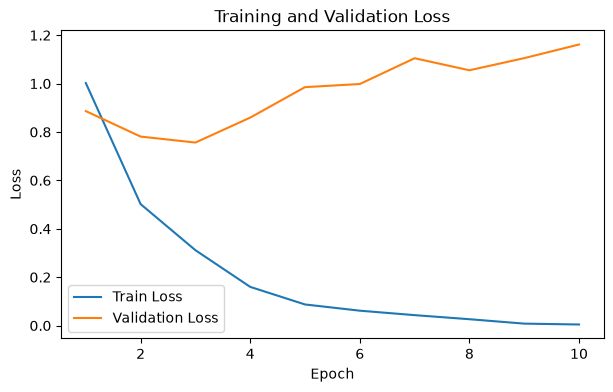

In [73]:
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(7, 4))

plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.show()

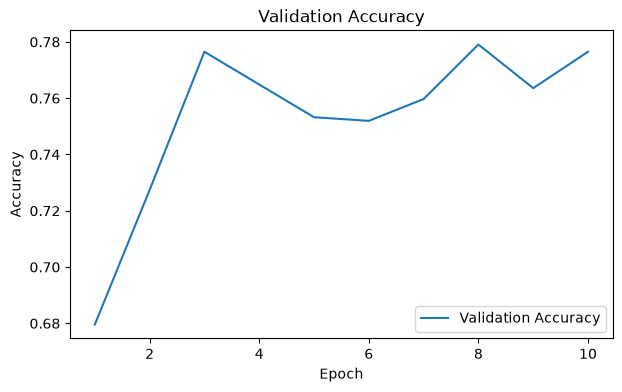

In [75]:
plt.figure(figsize=(7, 4))
plt.plot(epochs, val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy")

plt.legend()
plt.show()

# 9.1 — ذخیره بهترین مدل Baseline

In [ ]:
model = BaselineCNN(num_classes=7).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)
# بهتر است هنگام آموزش، بهترین وضعیت مدل را ذخیره کنیم.
#چرا مدل جدید؟
# چون می‌خواهیم Baseline را از ابتدا دوباره آموزش بدهیم، اما این بار هر وقت 
# validation بهتر شد، مدل را ذخیره کنیم.

# 9.2 — Training Loop

In [78]:
num_epochs = 10
train_losses = []
val_losses = []
val_accuracies = []
best_val_accuracy = 0.0
best_epoch = 0

for epoch in range(num_epochs):

    # Training
    model.train()
    train_running_loss = 0.0
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_running_loss += loss.item()

    train_loss = train_running_loss / len(train_loader)


    # Validation
    model.eval()
    val_running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item()
            predictions = outputs.argmax(dim=1)

            total += labels.size(0)
            correct += (predictions == labels).sum().item()

    val_loss = val_running_loss / len(val_loader)
    val_accuracy = correct / total

    # ذخیره نتایج
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    # Save Best Model
    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy
        best_epoch = epoch + 1

        torch.save(
            model.state_dict(),
            "../06_training/best_baseline_cnn.pth"
        )
        print("  --> Best model saved!")

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Val Accuracy: {val_accuracy:.4f}"
    )

print()
print("Best Epoch:", best_epoch)
print("Best Validation Accuracy:", best_val_accuracy)

  --> Best model saved!
Epoch [1/10] Train Loss: 0.5829 Val Loss: 0.5360 Val Accuracy: 0.8204
Epoch [2/10] Train Loss: 0.2994 Val Loss: 0.6645 Val Accuracy: 0.7804
Epoch [3/10] Train Loss: 0.1427 Val Loss: 0.5515 Val Accuracy: 0.8178
  --> Best model saved!
Epoch [4/10] Train Loss: 0.0663 Val Loss: 0.5938 Val Accuracy: 0.8217
  --> Best model saved!
Epoch [5/10] Train Loss: 0.0322 Val Loss: 0.6361 Val Accuracy: 0.8320
Epoch [6/10] Train Loss: 0.0134 Val Loss: 0.6662 Val Accuracy: 0.8295
Epoch [7/10] Train Loss: 0.0070 Val Loss: 0.7011 Val Accuracy: 0.8307
  --> Best model saved!
Epoch [8/10] Train Loss: 0.0027 Val Loss: 0.6902 Val Accuracy: 0.8372
  --> Best model saved!
Epoch [9/10] Train Loss: 0.0013 Val Loss: 0.6994 Val Accuracy: 0.8437
Epoch [10/10] Train Loss: 0.0009 Val Loss: 0.7103 Val Accuracy: 0.8437

Best Epoch: 9
Best Validation Accuracy: 0.8436692506459949


# 9.3 — ارزیابی Baseline روی Validation

In [ ]:
# load model
model.load_state_dict(
    torch.load(
        "../06_training/best_baseline_cnn.pth",
        map_location=device
    )
)
model = model.to(device)
model.eval()
print("Best Baseline Model Loaded")

Best Baseline Model Loaded


In [80]:
all_predictions = []
all_labels = []
model.eval()
with torch.no_grad():
    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        predictions = outputs.argmax(dim=1)

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# 9.4 — Precision , Recall , F1 , confusion_matrix

In [85]:
accuracy = accuracy_score(all_labels, all_predictions)
precision = precision_score(all_labels, all_predictions, average="macro")
recall = recall_score(all_labels, all_predictions, average="macro")
f1 = f1_score(all_labels, all_predictions, average="macro")
cm = confusion_matrix(all_labels, all_predictions)

print("Validation Accuracy :", accuracy)
print("Validation Precision:", precision)
print("Validation Recall   :", recall)
print("Validation F1 Score :", f1)
print('confusion_matrix    :\n',cm)

Validation Accuracy : 0.8436692506459949
Validation Precision: 0.8507231595246056
Validation Recall   : 0.8400577945831958
Validation F1 Score : 0.8448711039415147
confusion_matrix    :
 [[ 56   0   9   3   1   0   3]
 [  0  77  11   2   1   2   0]
 [  5   9 155  10   2   1   7]
 [  0   0  15  63   0   0   0]
 [  3   1   1   0  85   1   9]
 [  0   0   3   2   4  88   0]
 [  2   0   4   0   9   1 129]]


In [ ]:
# macro ابتدا معیار را برای هر کلاس جداگانه محاسبه می‌کند و سپس میانگین می‌گیرد.

# این برای پروژه ما مهم است چون تعداد تصاویر کلاس‌ها کاملاً برابر نیست؛
#  مثلاً kamyun نمونه‌های بیشتری از ambulance دارد.

# پس نمی‌خواهیم فقط کلاس‌های پرتعداد روی معیار کلی اثر زیادی بگذارند.

# قطر اصلی ماتریس = پیش‌بینی‌های درست
# خارج از قطر = خطاهای مدل

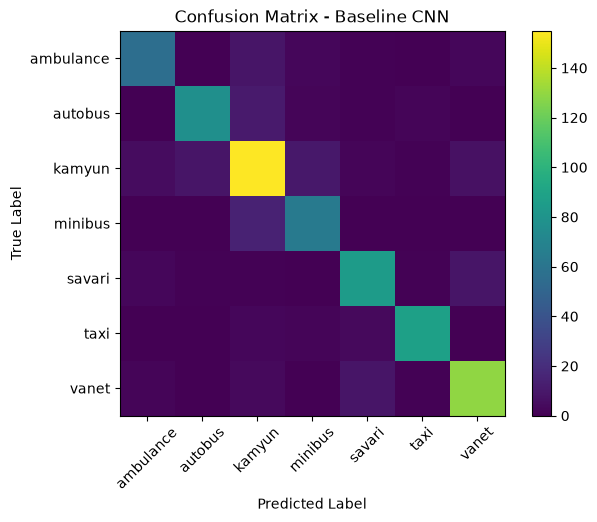

In [ ]:
classes = [
    'ambulance',
    'autobus',
    'kamyun',
    'minibus',
    'savari',
    'taxi',
    'vanet'
]
plt.figure(figsize=(7, 5))
plt.imshow(cm)
plt.xticks(
    range(len(classes)),
    classes,
    rotation=45
)
plt.yticks(
    range(len(classes)),
    classes
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Baseline CNN")
plt.colorbar()
plt.show()

# classification_report

In [88]:
report = classification_report(all_labels, all_predictions, target_names=classes)
print(report)

              precision    recall  f1-score   support

   ambulance       0.85      0.78      0.81        72
     autobus       0.89      0.83      0.86        93
      kamyun       0.78      0.82      0.80       189
     minibus       0.79      0.81      0.80        78
      savari       0.83      0.85      0.84       100
        taxi       0.95      0.91      0.93        97
       vanet       0.87      0.89      0.88       145

    accuracy                           0.84       774
   macro avg       0.85      0.84      0.84       774
weighted avg       0.85      0.84      0.84       774

